# Cell Crawling BTP — Version 3 (Full 2D Model)

## Phase Field + Actin Polarization + Intracellular Flow + Active Stress + Substrate Adhesion

### What Version 3 adds

Version 1 solved two fields, $\phi$ and $\mathbf P$, and set the fluid velocity
to zero. The cell could only translate rigidly: it stayed a perfect disc with
aspect ratio $1.00$–$1.01$ for the whole run.

Version 3 is the **complete** model of Tjhung *et al.*, *Nat. Commun.* **6**,
5420 (2015), in two dimensions. Everything that was switched off is now on:

| ingredient | Version 1 | Version 3 |
|---|---|---|
| cell field $\phi$ | yes | yes |
| actin polarization $\mathbf P$ | yes | yes |
| active treadmilling $w_0\mathbf P$ | yes | yes |
| **intracellular flow $\mathbf v$** | $\mathbf v=0$ | **incompressible Stokes solve** |
| **active (contractile) stress $\zeta$** | absent | **$\sigma^{act}_{\alpha\beta}=-\zeta\phi P_\alpha P_\beta$** |
| **elastic / Frank stress** | absent | **full Eq. (6)** |
| **interfacial (capillary) stress** | absent | **$-\phi\nabla\mu_\phi$** |
| **vorticity $\mathbf\Omega$ and flow alignment $\chi\mathbf D$** | absent | **present** |
| **boundary anchoring $\beta$** | wired but $=0$ | **active control parameter** |
| **substrate adhesion** | absent | **friction $\xi$** |
| volume conservation | drifted $4.5\%$ | **exact to $10^{-16}$** |

### Geometry: why a top view

The paper works in a quasi-2D vertical slice (its Fig. 1) and in full 3D (its
Figs. 2–4). We work in the **top view** $(x,y)$, the same plane as your Version
1, because that is the plane in which the cell morphologies of the paper's Fig. 2
are actually displayed — fried egg, lamellipodium, phagocytic cup, pseudopod are
all *top-view* shapes.

The price of a top view is that the substrate is no longer part of the
computational domain, so the paper's no-slip wall has to be represented some
other way. We use a **depth-averaged substrate friction** $-\xi\mathbf v$ in the
force balance. This is standard for thin crawling cells, and it is exactly the
description of adhesion that Leoni & Sens, *Phys. Rev. Lett.* **118**, 228101
(2017) arrive at: in their Eq. (5) a carpet of stochastic linkers, averaged over
many binding and unbinding events, is *equivalent to an effective friction*
$F^{sub}=-(\gamma_s+k\langle\chi\rangle/\kappa_-)\dot x$. Their $\xi$ is our
$\xi$. Section 12 examines what it controls, and where our model departs from
their prediction.

## 1. The full model

### Free energy (paper Eq. 1)

$$
F[\phi,\mathbf P]=\int d^2r\;\Big\{
\underbrace{a\,\phi^{2}(\phi-1)^{2}}_{\text{bulk: cell or exterior}}
+\underbrace{\tfrac{\varepsilon^{2}}{2}|\nabla\phi|^{2}}_{\text{interfacial tension}}
-\underbrace{\tfrac{\alpha}{2}\Big(\tfrac{\phi\tau-\phi_{cr}}{\phi_{cr}}\Big)|\mathbf P|^{2}
+\tfrac{\alpha}{4}|\mathbf P|^{4}}_{\text{polar order inside the cell}}
+\underbrace{\tfrac{\kappa}{2}(\nabla\mathbf P)^{2}}_{\text{Frank elasticity}}
+\underbrace{\beta\,\mathbf P\cdot\nabla\phi}_{\text{anchoring}}
\Big\}
$$

We take $\tau=1$ everywhere and $\phi_{cr}=1/2$, exactly as the paper does for
all of its 3D work. Then the polar bulk term is
$-\tfrac{\alpha}{2}(2\phi-1)|\mathbf P|^{2}$, so minimising gives
$|\mathbf P|^{2}=2\phi-1$: the polarization saturates at $|\mathbf P|=1$ deep
inside the cell and vanishes outside, smoothly across the interface. Version 1
used a hard `(phi > 0.5)` step here instead, which placed a discontinuity right
at the interface.

$\beta$ is the **anchoring strength**. For $\beta>0$ the polarization prefers to
point outward, normal to the cell boundary; for $\beta<0$, inward. It will turn
out to be the single most important shape parameter.

### Chemical potential and molecular field

Differentiating $F$:

$$
\mu_\phi=\frac{\delta F}{\delta\phi}
=2a\,\phi(\phi-1)(2\phi-1)-\varepsilon^{2}\nabla^{2}\phi
-\alpha|\mathbf P|^{2}-\beta\,\nabla\cdot\mathbf P
$$

$$
\mathbf h=\frac{\delta F}{\delta\mathbf P}
=\big[-\alpha(2\phi-1)+\alpha|\mathbf P|^{2}\big]\mathbf P
-\kappa\nabla^{2}\mathbf P+\beta\nabla\phi
$$

Note that both fields feel each other **thermodynamically**, through the
$-\alpha|\mathbf P|^2$ and $-\beta\nabla\cdot\mathbf P$ terms in $\mu_\phi$ and
the $\beta\nabla\phi$ term in $\mathbf h$. Version 1 had no such coupling: the
polarization was pushed around by $\phi$ but never pushed back.

## 2. Equations of motion

### Cell field (paper Eq. 8)

$$
\boxed{\;\frac{\partial\phi}{\partial t}+\nabla\cdot\big[\phi\,(\mathbf v+w_0\mathbf P)\big]=-M\big[\mu_\phi-\Lambda\, g(\phi)\big]\;}
$$

The material is advected by the **sum** of the fluid velocity and the
treadmilling velocity; $w_0$ is the speed at which each filament self-propels
along its own tangent relative to the fluid. The right-hand side is discussed in
Section 5.

### Polarization (paper Eq. 9)

$$
\boxed{\;\frac{\partial\mathbf P}{\partial t}+\big[(\mathbf v+w_0\mathbf P)\cdot\nabla\big]\mathbf P
=-\mathbf\Omega\cdot\mathbf P+\chi\,\mathbf D\cdot\mathbf P-\frac{1}{\Gamma}\mathbf h\;}
$$

with $W_{\alpha\beta}=\partial_\alpha v_\beta$ and
$\mathbf D=\tfrac12(W+W^{T})$, $\mathbf\Omega=\tfrac12(W-W^{T})$. In 2D
$\mathbf\Omega$ has a single component, so $-\mathbf\Omega\cdot\mathbf P$ is a
rigid rotation of $\mathbf P$ at half the local vorticity, and
$\chi\mathbf D\cdot\mathbf P$ aligns $\mathbf P$ with the straining direction of
the flow. Both terms are new in Version 3 and both vanish identically when
$\mathbf v=0$.

### Force balance (paper Eqs. 3–7, plus adhesion)

Cells crawl at Reynolds number $\sim10^{-5}$, so we drop inertia and keep the
**Stokes** limit of the paper's Navier–Stokes equation, adding the substrate
friction that replaces its no-slip wall:

$$
\boxed{\;0=-\nabla p+\eta\nabla^{2}\mathbf v-\xi\mathbf v+\mathbf f,\qquad \nabla\cdot\mathbf v=0\;}
$$

$$
f_\alpha=\partial_\beta\big(\sigma^{act}_{\alpha\beta}+\sigma^{el}_{\alpha\beta}\big)\;-\;\phi\,\partial_\alpha\mu_\phi
$$

$$
\sigma^{act}_{\alpha\beta}=-\zeta\phi P_\alpha P_\beta,
\qquad
\sigma^{el}_{\alpha\beta}=\tfrac12(P_\alpha h_\beta-P_\beta h_\alpha)
-\tfrac{\chi}{2}(P_\alpha h_\beta+P_\beta h_\alpha)
-\kappa\,\partial_\alpha P_\gamma\partial_\beta P_\gamma
$$

$\zeta<0$ is contractile, which is the actomyosin case: with $\mathbf P$ along
$\hat x$, $\sigma^{act}_{xx}=|\zeta|\phi$ and the resulting force
$|\zeta|\partial_x\phi$ points inward at the front and forward at the rear, i.e.
it squeezes the cell along its polarization axis.

The last term $-\phi\nabla\mu_\phi$ is the capillary force. It is the paper's
$\sigma^{interface}$ (Eq. 7) written in potential form, which is equivalent
because the two differ by a gradient and gradients are removed by the pressure.
Using it directly avoids differentiating a stress tensor that contains
$\partial f/\partial(\partial_\beta\phi)$.

## 3. Numerical strategy

Three choices matter.

**Spectral Stokes solve.** The domain is periodic in both directions, so we
solve the force balance in Fourier space. Taking $k_\alpha$ of the transformed
equation and using $\mathbf k\cdot\hat{\mathbf v}=0$ eliminates the pressure at
once, leaving

$$
\hat{\mathbf v}(\mathbf k)=\frac{1}{\xi+\eta k^{2}}
\Big(\hat{\mathbf f}-\hat{\mathbf k}\,(\hat{\mathbf k}\cdot\hat{\mathbf f})\Big),
$$

a **Leray projection** followed by a division. No iteration, no pressure
Poisson solve, no time-step penalty from the viscous term — one FFT pair per
step. Note that friction is what makes the $\mathbf k=0$ mode well defined; a
periodic Stokes problem with $\xi=0$ has no solution unless the net force
vanishes.

**Exactly conserved volume.** As in Version 2: conservative flux-form advection
plus an interface-weighted Lagrange multiplier. See Section 5.

**Box size matters.** The domain is periodic and the cell is tracked by rolling
the arrays, so the box has to be large enough that the cell never wraps onto
itself. The strongly anchored runs below reach aspect ratios above $4$, which for
$R_0=13$ means an extent of about $55$ in a box of $80$. `run_simulation` prints a
warning if $\phi>1/2$ ever comes within a few cells of the edge; if you see it,
raise `L`. (An earlier version of this notebook used $R_0=15$ and produced what
looked like a shape *oscillation* in the $\beta=0.5$ run — it was the cell
wrapping the box and corrupting the centre-of-mass measurement, not physics.)

**Explicit time stepping**, which is safe because the Stokes solve is exact and
every remaining operator is second order. The binding constraint is interface
diffusion, $dt<dx^{2}/(4M\varepsilon^{2})\approx0.028$; we use $dt=0.01$.

The cell is kept in the middle of the box by rolling all arrays by a whole
number of cells. An integer roll conserves mass exactly and introduces no
interpolation error; the accumulated shifts give the true trajectory.

# 4. Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# Cell Crawling BTP - Version 3 (full 2D model)
#
#   phi(x,y,t)     : cell phase field
#   P(x,y,t)       : actin polarization
#   v(x,y,t)       : intracellular flow (Stokes + substrate friction)
#
#   u = v + w0 P   : velocity that transports the cell material
#
# ============================================================


# ---------------- grid ----------------
N = 128                  # 160 changes the answers by ~1% and costs 1.6x more
L = 80.0


# ---------------- cell ----------------
R0 = 13.0                # initial radius (see the box-size note below)
eps = 1.5                # diffuse interface width
a_phi = 1.0              # double-well amplitude
M_phi = 1.0              # phase-field relaxation rate


# ---------------- polarization ----------------
a_pol = 0.5              # polar bulk strength, gives |P| = 1 inside the cell
kappa = 1.0              # Frank elastic constant
Gamma = 1.0              # rotational viscosity
chi = 1.1                # flow alignment; |chi| > 1 is flow aligning


# ---------------- activity ----------------
w0 = 1.0                 # actin treadmilling rate
zeta = -1.0              # active stress; NEGATIVE = contractile (actomyosin)
beta = 0.25              # anchoring of P at the cell boundary; > 0 is outward


# ---------------- substrate and fluid ----------------
eta = 1.0                # cytoplasmic shear viscosity
xi = 1.0                 # substrate friction = adhesion strength


# ---------------- time ----------------
dt = 0.01
sample_every = 100


# Set QUICK = True while developing: every run gets shorter.
QUICK = False
TS = 0.35 if QUICK else 1.0

print(f"grid {N} x {N},  dx = {L/N:.4f},  interface spans "
      f"{np.sqrt(2)*eps/(L/N):.1f} cells")
print(f"stability: dt must be < dx^2/(4 M eps^2) = "
      f"{(L/N)**2/(4*M_phi*eps**2):.4f};  using dt = {dt}")

grid 128 x 128,  dx = 0.6250,  interface spans 3.4 cells
stability: dt must be < dx^2/(4 M eps^2) = 0.0434;  using dt = 0.01


# 5. Grid, derivatives, and conservative advection

`setup_grid` fills in the real-space and Fourier grids. Everything is periodic,
so real-space derivatives are plain `np.roll` central differences and the
wavenumbers come from `np.fft.fftfreq`.

### Volume conservation

Version 1 advected the cell field as $\mathbf u\cdot\nabla\phi$ and then applied
`clip(0,1)`, which leaked $4.5\%$ of the area. Here the advection is written in
**flux form**, evaluated on cell faces,

$$
F^{x}_{i+1/2,j}=\tfrac12(\phi_{i,j}+\phi_{i+1,j})\cdot\tfrac12(u^x_{i,j}+u^x_{i+1,j}),
$$

so that whatever leaves one cell enters its neighbour and the sum over the
periodic grid telescopes to zero.

The relaxation is then made conserving by subtracting a spatially uniform
Lagrange multiplier, weighted by $g(\phi)=\phi(1-\phi)$ so that it acts only
where the interface is:

$$
\frac{\partial\phi}{\partial t}\Big|_{\text{relax}}=-M\big[\mu_\phi-\Lambda g(\phi)\big],
\qquad
\Lambda=\frac{\int\mu_\phi\,dA}{\int g\,dA}.
$$

Integrating over the domain, the bracket integrates to zero by construction, so
$\frac{d}{dt}\int\phi\,dA=0$ **exactly** — not approximately. This is the
conservative Allen–Cahn equation of Rubinstein and Sternberg. It keeps a
second-order time-step restriction, whereas the paper's Cahn–Hilliard form
$\nabla\cdot(M\nabla\mu)$ is fourth order and explicitly would need
$dt\sim dx^{4}$. $\Lambda$ is uniform and conjugate to volume, so it acts as an
internal pressure. There is no `clip` anywhere; the double well bounds $\phi$ on
its own.

In [2]:
def setup_grid(N_=N, L_=L):
    global N, L, dx, X, Y, KX, KY, K2, K2_safe

    N, L = N_, L_
    dx = L / N

    coords = (np.arange(N) - N // 2) * dx
    X, Y = np.meshgrid(coords, coords, indexing="ij")

    k1 = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)
    KX, KY = np.meshgrid(k1, k1, indexing="ij")
    K2 = KX**2 + KY**2

    K2_safe = K2.copy()
    K2_safe[0, 0] = 1.0                 # avoid 0/0 in the projection



setup_grid()


# ============================================================
# Derivatives (periodic, central differences)
# ============================================================

def d_dx(a):
    return (np.roll(a, -1, axis=0) - np.roll(a, 1, axis=0)) / (2.0 * dx)


def d_dy(a):
    return (np.roll(a, -1, axis=1) - np.roll(a, 1, axis=1)) / (2.0 * dx)


def laplacian(a):
    return (np.roll(a, -1, axis=0) + np.roll(a, 1, axis=0)
            + np.roll(a, -1, axis=1) + np.roll(a, 1, axis=1)
            - 4.0 * a) / dx**2


# ============================================================
# Conservative advection:  div( phi u )  on cell faces
# ============================================================

def divergence_of_flux(phi, ux, uy):
    Fx = 0.5 * (phi + np.roll(phi, -1, axis=0)) * 0.5 * (ux + np.roll(ux, -1, axis=0))
    Fy = 0.5 * (phi + np.roll(phi, -1, axis=1)) * 0.5 * (uy + np.roll(uy, -1, axis=1))

    return ((Fx - np.roll(Fx, 1, axis=0))
            + (Fy - np.roll(Fy, 1, axis=1))) / dx

# 6. Thermodynamics: $\mu_\phi$, $\mathbf h$, and the free energy

Direct transcription of the derivatives written out in Section 1. The free
energy itself is only needed as a diagnostic, but it is a strong test: with all
activity switched off it must decrease monotonically.

In [3]:
def chemical_potential_phi(phi, P2, dPx_dx, dPy_dy):
    return (2.0 * a_phi * phi * (phi - 1.0) * (2.0 * phi - 1.0)
            - eps**2 * laplacian(phi)
            - a_pol * P2
            - beta_run * (dPx_dx + dPy_dy))


def molecular_field_P(phi, Px, Py, P2):
    bulk = -a_pol * (2.0 * phi - 1.0) + a_pol * P2

    hx = bulk * Px - kappa_run * laplacian(Px) + beta_run * d_dx(phi)
    hy = bulk * Py - kappa_run * laplacian(Py) + beta_run * d_dy(phi)

    return hx, hy


def total_free_energy(phi, Px, Py, P2):
    gx, gy = d_dx(phi), d_dy(phi)

    Pxx, Pxy = d_dx(Px), d_dy(Px)
    Pyx, Pyy = d_dx(Py), d_dy(Py)

    density = (a_phi * phi**2 * (phi - 1.0)**2
               + 0.5 * eps**2 * (gx**2 + gy**2)
               - 0.5 * a_pol * (2.0 * phi - 1.0) * P2
               + 0.25 * a_pol * P2**2
               + 0.5 * kappa_run * (Pxx**2 + Pxy**2 + Pyx**2 + Pyy**2)
               + beta_run * (Px * gx + Py * gy))

    return density.sum() * dx**2

# 7. Stresses and the body force

All four stress contributions of Section 2, assembled and differentiated. The
elastic stress splits naturally into three pieces:

- an **antisymmetric** part $\tfrac12(P_\alpha h_\beta-P_\beta h_\alpha)$, which
  in 2D has the single independent component
  $\tfrac12(P_xh_y-P_yh_x)$ — the torque the polarization exerts on the fluid;
- a **symmetric** part $-\tfrac{\chi}{2}(P_\alpha h_\beta+P_\beta h_\alpha)$,
  the counterpart of the flow-alignment term in the $\mathbf P$ equation;
- the **Frank stress** $-\kappa\partial_\alpha P_\gamma\partial_\beta P_\gamma$,
  which is symmetric and always present when $\mathbf P$ is distorted.

In [4]:
def body_force(phi, Px, Py, mu, hx, hy):

    # ---------- active stress:  -zeta phi P_a P_b ----------
    Axx = -zeta_run * phi * Px * Px
    Axy = -zeta_run * phi * Px * Py
    Ayy = -zeta_run * phi * Py * Py

    # ---------- elastic stress ----------
    torque = 0.5 * (Px * hy - Py * hx)

    Exx = -chi_run * Px * hx
    Exy = torque - 0.5 * chi_run * (Px * hy + Py * hx)
    Eyx = -torque - 0.5 * chi_run * (Py * hx + Px * hy)
    Eyy = -chi_run * Py * hy

    # ---------- Frank stress:  -kappa d_a P_g d_b P_g ----------
    Pxx, Pxy = d_dx(Px), d_dy(Px)
    Pyx, Pyy = d_dx(Py), d_dy(Py)

    Kxx = -kappa_run * (Pxx * Pxx + Pyx * Pyx)
    Kxy = -kappa_run * (Pxx * Pxy + Pyx * Pyy)
    Kyy = -kappa_run * (Pxy * Pxy + Pyy * Pyy)

    # ---------- total, then f_a = d_b sigma_ab ----------
    Sxx = Axx + Exx + Kxx
    Sxy = Axy + Exy + Kxy
    Syx = Axy + Eyx + Kxy
    Syy = Ayy + Eyy + Kyy

    fx = d_dx(Sxx) + d_dy(Sxy) - phi * d_dx(mu)     # last term = capillary
    fy = d_dx(Syx) + d_dy(Syy) - phi * d_dy(mu)

    return fx, fy

# 8. The Stokes solve

Two lines of algebra and two FFTs. Writing $\hat{\mathbf f}$ for the transformed
body force, the longitudinal component
$\hat{\mathbf k}(\hat{\mathbf k}\cdot\hat{\mathbf f})$ is exactly what the
pressure cancels, so subtracting it enforces $\nabla\cdot\mathbf v=0$ and
eliminates $p$ simultaneously. What remains is divided by $\xi+\eta k^{2}$.

The $\mathbf k=0$ mode is set to zero. For a self-propelled object all the
stresses are divergences and the capillary force differs from one by a gradient,
so the net force over a periodic domain vanishes identically in the continuum;
zeroing the mode simply removes the discretisation residue instead of letting it
accumulate as a spurious drift of the whole box.

In [5]:
def stokes_solve(fx, fy):
    fx_h = np.fft.fft2(fx)
    fy_h = np.fft.fft2(fy)

    # remove the longitudinal part  ->  incompressible, pressure eliminated
    longitudinal = (KX * fx_h + KY * fy_h) / K2_safe
    fx_h = fx_h - KX * longitudinal
    fy_h = fy_h - KY * longitudinal

    screened = xi_run + eta * K2

    vx_h = fx_h / screened
    vy_h = fy_h / screened

    vx_h[0, 0] = 0.0
    vy_h[0, 0] = 0.0

    return np.real(np.fft.ifft2(vx_h)), np.real(np.fft.ifft2(vy_h))

# 9. Initial conditions

The cell is a disc of radius $R_0$ with a `tanh` interface, optionally squashed
into an ellipse (used by the passive test in Section 11).

Two initial polarizations are offered:

- `"uniform"`: $\mathbf P\approx(1,0)$ with a little noise. This is what Version
  1 used, and it is the natural starting point for a crawling cell.
- `"radial"`: $\mathbf P$ pointing radially outward, an **aster** with a $+1$
  topological defect at the centre. The paper reaches this state by imposing
  strong outward anchoring; starting there directly saves a long transient.

In [6]:
def initialize(R0=R0, eps=eps, ecc=0.0, P_init="uniform",
               noise=0.02, seed=7):

    radius = np.sqrt((X / (1.0 + ecc))**2 + (Y * (1.0 + ecc))**2)
    phi = 0.5 * (1.0 - np.tanh((radius - R0) / (np.sqrt(2.0) * eps)))

    rng = np.random.default_rng(seed)

    if P_init == "uniform":
        Px = phi * (1.0 + noise * rng.standard_normal(phi.shape))
        Py = phi * (noise * rng.standard_normal(phi.shape))

    elif P_init == "radial":
        r = np.sqrt(X**2 + Y**2) + 1e-9
        Px, Py = phi * X / r, phi * Y / r

    else:                                   # "zero" - for the passive test
        Px = phi * noise * rng.standard_normal(phi.shape)
        Py = phi * noise * rng.standard_normal(phi.shape)

    magnitude = np.sqrt(Px**2 + Py**2) + 1e-12
    Px = phi * Px / magnitude
    Py = phi * Py / magnitude

    return phi, Px, Py

# 10. Diagnostics

Volume is fixed by construction, so the informative quantities describe **shape**
and **motion**:

- **centre of mass** and **crawl speed**. Because the box is periodic, $x_{cm}$
  is a *circular* mean, unwrapped with the accumulated re-centring shifts.
- **aspect ratio** from the eigenvalues of the second-moment tensor. Read
  together with the direction of motion this distinguishes a cell elongated
  *across* its path (keratocyte, fan) from one elongated *along* it (finger).
- **circularity** $4\pi A/\mathcal{P}^{2}$, which is $1$ for a disc and falls as
  the outline becomes convoluted. $\mathcal{P}=\int|\nabla\phi|\,dA$, which for a
  `tanh` profile equals the perimeter.
- **polarization order** $|\langle\mathbf P\rangle|$: near $1$ for a uniformly
  polarized cell, near $0$ for an aster.
- **splay** $\langle\nabla\cdot\mathbf P\rangle$: positive for an outward aster.
- **maximum flow speed**, to see how strong the intracellular flow actually is
  relative to $w_0$.
- **free energy** and **volume error**, the two regression tests.

In [7]:
def centre_of_mass(phi):
    mass = phi.sum()
    return (X * phi).sum() / mass, (Y * phi).sum() / mass


def touches_boundary(phi, margin=6):
    # the periodic box must be big enough that the cell never wraps
    inside = phi > 0.5
    return bool(inside[:margin].any() or inside[-margin:].any()
                or inside[:, :margin].any() or inside[:, -margin:].any())


def calculate_diagnostics(phi, Px, Py, vx, vy, P2):

    mass = phi.sum()

    # ---------------- area, perimeter, circularity ----------------
    inside = phi > 0.5
    area = inside.sum() * dx**2

    gx, gy = d_dx(phi), d_dy(phi)
    perimeter = np.sqrt(gx**2 + gy**2).sum() * dx**2
    circularity = 4.0 * np.pi * area / max(perimeter**2, 1e-12)

    # ---------------- second moments -> aspect ratio ----------------
    xc = (X * phi).sum() / mass
    yc = (Y * phi).sum() / mass
    Xc, Yc = X - xc, Y - yc

    Mxx = (Xc**2 * phi).sum() / mass
    Myy = (Yc**2 * phi).sum() / mass
    Mxy = (Xc * Yc * phi).sum() / mass

    ev = np.linalg.eigvalsh(np.array([[Mxx, Mxy], [Mxy, Myy]]))
    minor = np.sqrt(max(ev[0], 1e-12))
    major = np.sqrt(max(ev[1], 1e-12))

    # ---------------- polarization and flow ----------------
    order = np.hypot((Px * phi).sum() / mass, (Py * phi).sum() / mass)
    splay = ((d_dx(Px) + d_dy(Py)) * phi).sum() / mass

    return {
        "volume": mass,
        "area": area,
        "circularity": circularity,
        "major": major,
        "minor": minor,
        "aspect": major / minor,
        "P_order": order,
        "splay": splay,
        "v_max": np.sqrt(vx**2 + vy**2).max(),
        "free_energy": total_free_energy(phi, Px, Py, P2),
    }

# 11. The Version 3 time loop

Each step, in order:

**A.** $\mu_\phi$ and $\mathbf h$ from the current fields.

**B.** Body force from all four stresses, then the Stokes solve for $\mathbf v$.

**C.** $\mathbf u=\mathbf v+w_0\mathbf P$, the velocity that moves material.

**D.** $\phi$: conservative advection by $\mathbf u$ plus volume-conserving
relaxation.

**E.** $\mathbf P$: advection by $\mathbf u$, rotation by the vorticity,
alignment by the strain rate, relaxation by $-\mathbf h/\Gamma$.

**F.** Diagnostics, then re-centre by an integer roll.

The activity parameters are passed through module-level `*_run` variables so
that a single call can override `zeta`, `beta`, `xi`, `chi`, `kappa` without
touching the defaults — this is what the sweeps in Sections 13–15 use.

In [8]:
def run_simulation(w0=w0, zeta=zeta, beta=beta, xi=xi, chi=chi, kappa=kappa,
                   R0=R0, ecc=0.0, P_init="uniform", noise=0.02, seed=7,
                   t_final=200.0, dt=dt, sample_every=sample_every,
                   snapshot_times=(), state=None,
                   flow=True, freeze_P=False, verbose=True):

    global zeta_run, beta_run, xi_run, chi_run, kappa_run
    zeta_run, beta_run, xi_run = zeta, beta, xi
    chi_run, kappa_run = chi, kappa

    t_start = time.time()

    if state is None:
        phi, Px, Py = initialize(R0, eps, ecc, P_init, noise, seed)
    else:
        phi, Px, Py = (s.copy() for s in state)

    V0 = phi.sum()
    shift_x = shift_y = 0.0

    n_steps = int(round(t_final / dt))
    snap_steps = {int(round(t / dt)) for t in snapshot_times}

    snapshots = []
    diagnostics = {"time": [], "x_cm": [], "y_cm": []}

    vx = np.zeros_like(phi)
    vy = np.zeros_like(phi)

    for step in range(n_steps):

        P2 = Px**2 + Py**2

        # ---------- A. thermodynamic fields ----------
        mu = chemical_potential_phi(phi, P2, d_dx(Px), d_dy(Py))
        hx, hy = molecular_field_P(phi, Px, Py, P2)

        # ---------- B. force balance ----------
        if flow:
            fx, fy = body_force(phi, Px, Py, mu, hx, hy)
            vx, vy = stokes_solve(fx, fy)

        # ---------- C. transport velocity ----------
        ux = vx + w0 * Px
        uy = vy + w0 * Py

        # ---------- D. cell field, volume conserving ----------
        g = np.clip(phi * (1.0 - phi), 0.0, None)
        Lagrange = mu.sum() / g.sum()

        phi = phi + dt * (-divergence_of_flux(phi, ux, uy)
                          - M_phi * (mu - Lagrange * g))

        # ---------- E. polarization ----------
        if not freeze_P:
            dvx_dx, dvx_dy = d_dx(vx), d_dy(vx)
            dvy_dx, dvy_dy = d_dx(vy), d_dy(vy)

            Dxx, Dyy = dvx_dx, dvy_dy
            Dxy = 0.5 * (dvx_dy + dvy_dx)
            omega = 0.5 * (dvy_dx - dvx_dy)

            advection_Px = ux * d_dx(Px) + uy * d_dy(Px)
            advection_Py = ux * d_dx(Py) + uy * d_dy(Py)

            Px_new = Px + dt * (-advection_Px
                                - omega * Py
                                + chi * (Dxx * Px + Dxy * Py)
                                - hx / Gamma)
            Py_new = Py + dt * (-advection_Py
                                + omega * Px
                                + chi * (Dxy * Px + Dyy * Py)
                                - hy / Gamma)
            Px, Py = Px_new, Py_new
        else:
            Px = np.zeros_like(phi)
            Py = np.zeros_like(phi)

        # ---------- F. bookkeeping ----------
        if step in snap_steps:
            snapshots.append((step * dt, phi.copy(), Px.copy(), Py.copy(),
                              vx.copy(), vy.copy()))

        if step % sample_every == 0:
            xc, yc = centre_of_mass(phi)

            data = calculate_diagnostics(phi, Px, Py, vx, vy, Px**2 + Py**2)

            diagnostics["time"].append(step * dt)
            diagnostics["x_cm"].append(shift_x + xc)
            diagnostics["y_cm"].append(shift_y + yc)

            for key in data:
                diagnostics.setdefault(key, []).append(data[key])

            ix = int(round(-xc / dx))
            iy = int(round(-yc / dx))
            if ix or iy:
                phi = np.roll(np.roll(phi, ix, axis=0), iy, axis=1)
                Px = np.roll(np.roll(Px, ix, axis=0), iy, axis=1)
                Py = np.roll(np.roll(Py, ix, axis=0), iy, axis=1)
                shift_x -= ix * dx
                shift_y -= iy * dx

            if touches_boundary(phi):
                print(f"   ** WARNING: cell reached the box edge at "
                      f"t = {step*dt:.0f}; enlarge L")

        if not np.isfinite(phi).all():
            print(f"   ** diverged at t = {step*dt:.2f}")
            break

    diagnostics = {k: np.array(v) for k, v in diagnostics.items()}

    Vx = np.gradient(diagnostics["x_cm"], diagnostics["time"])
    Vy = np.gradient(diagnostics["y_cm"], diagnostics["time"])
    diagnostics["Vx"], diagnostics["Vy"] = Vx, Vy
    diagnostics["speed"] = np.hypot(Vx, Vy)
    diagnostics["volume_error"] = (phi.sum() - V0) / V0

    if verbose:
        print(f"   w0={w0:<5g} zeta={zeta:<7g} beta={beta:<7g} xi={xi:<6g} "
              f"[{time.time()-t_start:5.1f}s]  "
              f"dV/V={diagnostics['volume_error']:+.1e}  "
              f"speed={diagnostics['speed'][-3:].mean():.3f}  "
              f"aspect={diagnostics['aspect'][-1]:.2f}")

    return phi, Px, Py, vx, vy, diagnostics, snapshots

# 12. Visualization

The background is $\phi$. White arrows show either the polarization
$\mathbf P$ or the flow $\mathbf v$, and the orange arrow is the measured
direction of whole-cell motion — essential for reading the shapes, since a cell
elongated *across* its direction of travel (a keratocyte fan) and one elongated
*along* it (a finger) have the same aspect ratio.

In [9]:
def draw_cell(ax, phi, Ax, Ay, direction=None, stride=6,
              title=None, arrow_scale=None):

    ax.imshow(phi.T, origin="lower", vmin=0.0, vmax=1.0,
              extent=[-L / 2, L / 2, -L / 2, L / 2])

    ax.contour(X, Y, phi, [0.5], colors="white", linewidths=0.8)

    if arrow_scale is None:
        arrow_scale = 14.0 * (np.hypot(Ax, Ay).max() + 1e-12)

    ax.quiver(X[::stride, ::stride], Y[::stride, ::stride],
              Ax[::stride, ::stride], Ay[::stride, ::stride],
              color="white", scale=arrow_scale, width=0.004)

    if direction is not None:
        Vx, Vy = direction
        n = np.hypot(Vx, Vy)
        if n > 1e-6:
            ax.arrow(-0.42 * L, -0.42 * L, 0.17 * L * Vx / n, 0.17 * L * Vy / n,
                     color="orangered", width=0.017 * L, head_width=0.05 * L)
            ax.text(-0.46 * L, -0.32 * L, "motion", color="orangered", fontsize=8)
        else:
            ax.text(-0.46 * L, -0.40 * L, "not motile", color="orangered", fontsize=8)

    ax.set_xlim(-L / 2, L / 2)
    ax.set_ylim(-L / 2, L / 2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title:
        ax.set_title(title, fontsize=9)


def final_direction(d):
    return d["Vx"][-3:].mean(), d["Vy"][-3:].mean()

# 13. Test 0 — the passive limit

Before trusting any active result, the code has to get the *passive* physics
right. With $w_0=\zeta=\beta=0$ and $\mathbf P$ frozen at zero, the model reduces
to a viscous drop held together by interfacial tension. Three things must then
happen, and all three are non-trivial checks on the Stokes solve, the sign of the
capillary force, and the conservative advection:

1. an initially **elliptical** drop must relax to a **circle**;
2. the free energy must decrease **monotonically**;
3. the volume must be conserved and the flow must **die away** to zero.

If the sign of $-\phi\nabla\mu_\phi$ were wrong, the ellipse would elongate
instead and the run would blow up.

In [10]:
phi_p, Px_p, Py_p, vx_p, vy_p, diag_p, snaps_p = run_simulation(
    w0=0.0, zeta=0.0, beta=0.0, ecc=0.30, P_init="zero", freeze_P=True,
    t_final=100.0 * TS, snapshot_times=(0.0, 5.0, 20.0, 99.0 * TS))

F = diag_p["free_energy"]
print()
print(f"   aspect ratio    {diag_p['aspect'][0]:.3f}  ->  {diag_p['aspect'][-1]:.3f}")
print(f"   circularity     {diag_p['circularity'][0]:.3f}  ->  "
      f"{diag_p['circularity'][-1]:.3f}")
print(f"   free energy     {F[0]:.3f}  ->  {F[-1]:.3f}")
print(f"   max flow speed  {diag_p['v_max'][0]:.2e}  ->  {diag_p['v_max'][-1]:.2e}")
print()
print(f"   free energy decreases monotonically : {bool(np.all(np.diff(F) <= 1e-9))}")
print(f"   relative volume error               : {diag_p['volume_error']:+.2e}")

   w0=0     zeta=0       beta=0       xi=1      [ 22.3s]  dV/V=+0.0e+00  speed=0.000  aspect=1.01

   aspect ratio    1.689  ->  1.010
   circularity     0.884  ->  1.002
   free energy     30.488  ->  28.624
   max flow speed  2.16e+00  ->  6.48e-05

   free energy decreases monotonically : True
   relative volume error               : +0.00e+00


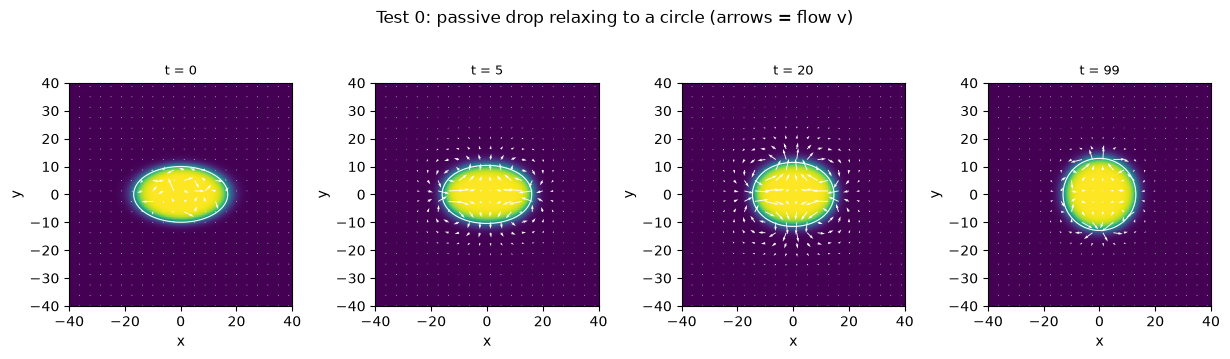

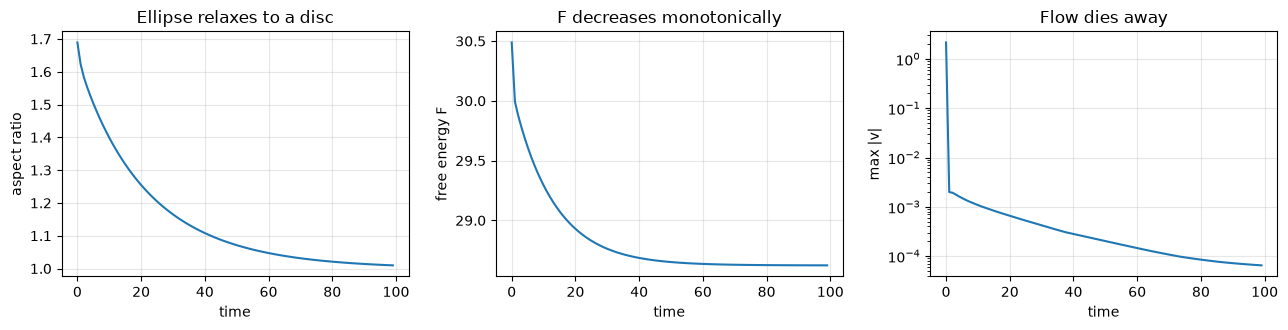

In [11]:
fig, axes = plt.subplots(1, len(snaps_p), figsize=(3.1 * len(snaps_p), 3.4))

for ax, (t, p, px, py, ux, uy) in zip(axes, snaps_p):
    draw_cell(ax, p, ux, uy, title=f"t = {t:.0f}")

fig.suptitle("Test 0: passive drop relaxing to a circle "
             "(arrows = flow v)", y=1.02)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

ax[0].plot(diag_p["time"], diag_p["aspect"])
ax[0].set_ylabel("aspect ratio")
ax[0].set_title("Ellipse relaxes to a disc")

ax[1].plot(diag_p["time"], diag_p["free_energy"])
ax[1].set_ylabel("free energy F")
ax[1].set_title("F decreases monotonically")

ax[2].semilogy(diag_p["time"], diag_p["v_max"])
ax[2].set_ylabel("max |v|")
ax[2].set_title("Flow dies away")

for a in ax:
    a.set_xlabel("time")
    a.grid(alpha=0.3)

fig.tight_layout()
plt.show()

# 14. Result 1 — the cell morphologies

Now the activity goes on. Following the paper, the morphology is selected by the
combination of treadmilling $w_0$, contractility $\zeta$ and anchoring $\beta$
(its Figs. 2 and 3). We fix $w_0=1$ and vary $\zeta$ and $\beta$.

| run | $\beta$ | $\zeta$ | $\mathbf P$ at $t=0$ | paper counterpart |
|---|---|---|---|---|
| 1 | $1.5$ | $-1$ | radial | fried egg, Fig. 2a–c / Fig. 4a |
| 2 | $0$ | $-0.3$ | uniform | weakly deformed motile cell |
| 3 | $0.25$ | $-1$ | uniform | lamellipodium / keratocyte, Fig. 2d–f |
| 4 | $0.5$ | $0$ | uniform | same family as 3, driven harder |

In [12]:
MORPHOLOGIES = [
    ("aster / fried egg", dict(w0=1.0, zeta=-1.0, beta=1.5, P_init="radial")),
    ("weakly deformed",   dict(w0=1.0, zeta=-0.3, beta=0.0)),
    ("lamellipodium",     dict(w0=1.0, zeta=-1.0, beta=0.25)),
    ("strongly fanned",   dict(w0=1.0, zeta=0.0,  beta=0.5)),
]

results = []
for name, kw in MORPHOLOGIES:
    print(name)
    results.append((name, kw) + run_simulation(t_final=250.0 * TS, **kw))

aster / fried egg


   w0=1     zeta=-1      beta=1.5     xi=1      [ 68.5s]  dV/V=-1.6e-16  speed=0.000  aspect=1.00
weakly deformed


   w0=1     zeta=-0.3    beta=0       xi=1      [ 68.4s]  dV/V=+3.3e-16  speed=0.799  aspect=1.14
lamellipodium


   w0=1     zeta=-1      beta=0.25    xi=1      [ 68.4s]  dV/V=+3.3e-16  speed=0.843  aspect=2.91
strongly fanned


   w0=1     zeta=0       beta=0.5     xi=1      [ 68.5s]  dV/V=+1.6e-16  speed=0.841  aspect=4.35


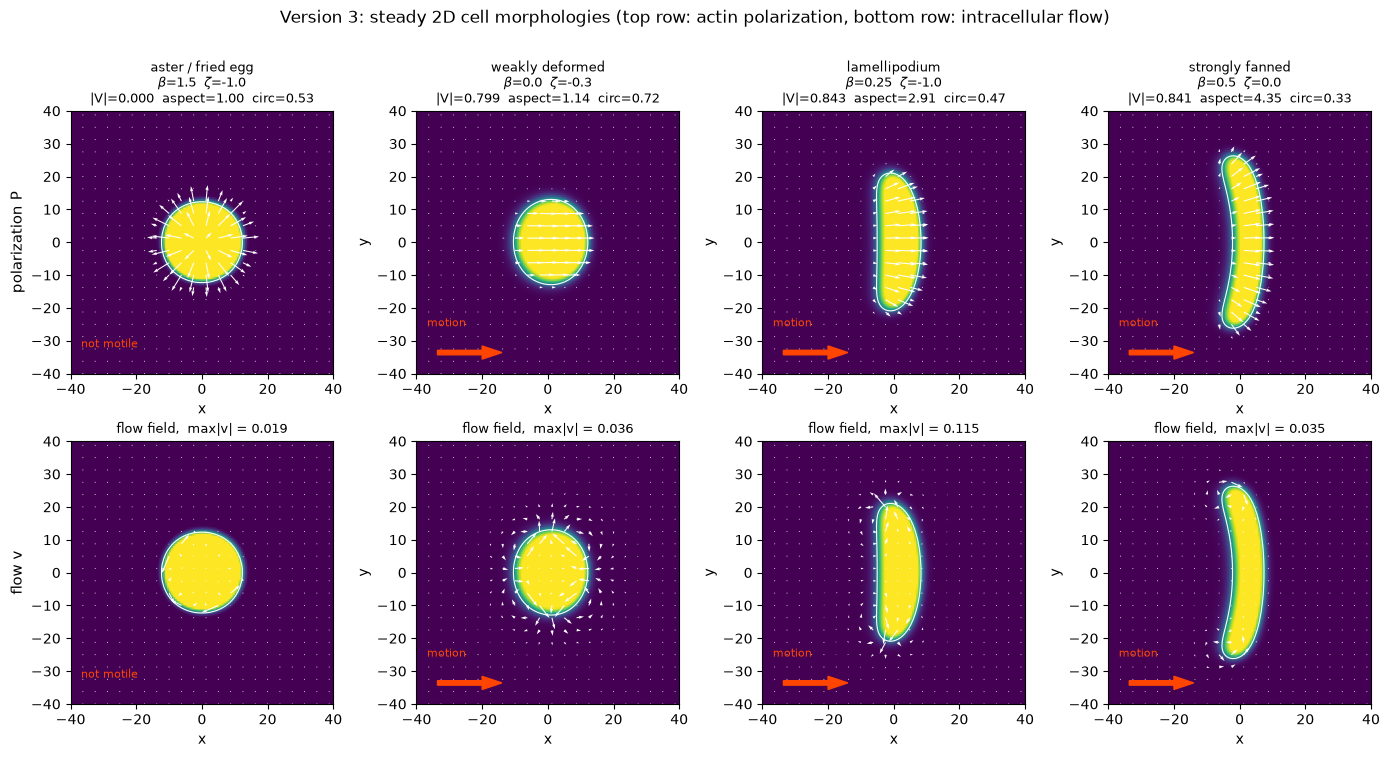

morphology                |V|   aspect    circ   |<P>|    splay   max|v|       dV/V
aster / fried egg       0.000     1.00   0.528   0.000  +0.1906    0.019   -1.6e-16
weakly deformed         0.799     1.14   0.718   0.959  -0.0089    0.036   +3.3e-16
lamellipodium           0.843     2.91   0.473   0.899  +0.0146    0.115   +3.3e-16
strongly fanned         0.841     4.35   0.330   0.812  +0.0402    0.035   +1.6e-16


In [13]:
fig, axes = plt.subplots(2, len(results), figsize=(3.5 * len(results), 7.4))

for j, (name, kw, phi, Px, Py, vx, vy, d, _) in enumerate(results):
    direction = final_direction(d)

    draw_cell(axes[0, j], phi, Px, Py, direction=direction,
              title=(f"{name}\n" + r"$\beta$" + f"={kw['beta']}  "
                     + r"$\zeta$" + f"={kw['zeta']}\n"
                     f"|V|={np.hypot(*direction):.3f}  "
                     f"aspect={d['aspect'][-1]:.2f}  "
                     f"circ={d['circularity'][-1]:.2f}"))

    draw_cell(axes[1, j], phi, vx, vy, direction=direction,
              title=f"flow field,  max|v| = {d['v_max'][-1]:.3f}")

axes[0, 0].set_ylabel("polarization P", fontsize=11)
axes[1, 0].set_ylabel("flow v", fontsize=11)

fig.suptitle("Version 3: steady 2D cell morphologies "
             "(top row: actin polarization, bottom row: intracellular flow)",
             y=1.01)
fig.tight_layout()
plt.show()

print(f"{'morphology':20s} {'|V|':>8s} {'aspect':>8s} {'circ':>7s} "
      f"{'|<P>|':>7s} {'splay':>8s} {'max|v|':>8s} {'dV/V':>10s}")
for name, kw, phi, Px, Py, vx, vy, d, _ in results:
    print(f"{name:20s} {np.hypot(*final_direction(d)):8.3f} "
          f"{d['aspect'][-1]:8.2f} {d['circularity'][-1]:7.3f} "
          f"{d['P_order'][-1]:7.3f} {d['splay'][-1]:+8.4f} "
          f"{d['v_max'][-1]:8.3f} {d['volume_error']:+10.1e}")

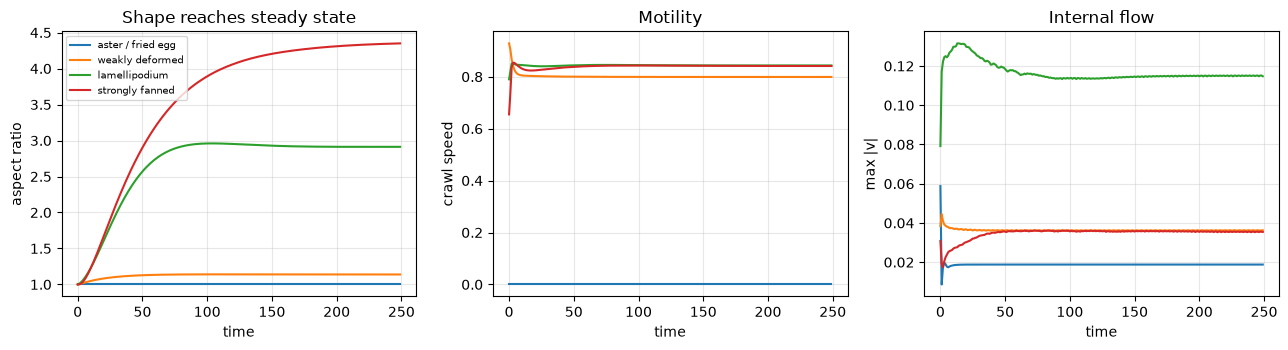

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

for name, kw, phi, Px, Py, vx, vy, d, _ in results:
    ax[0].plot(d["time"], d["aspect"], label=name)
    ax[1].plot(d["time"], d["speed"], label=name)
    ax[2].plot(d["time"], d["v_max"], label=name)

ax[0].set_ylabel("aspect ratio"); ax[0].set_title("Shape reaches steady state")
ax[1].set_ylabel("crawl speed");  ax[1].set_title("Motility")
ax[2].set_ylabel("max |v|");      ax[2].set_title("Internal flow")

for a in ax:
    a.set_xlabel("time"); a.grid(alpha=0.3)
ax[0].legend(fontsize=7)

fig.tight_layout()
plt.show()

### Reading the results

**The aster is not motile.** With strong outward anchoring the polarization locks
into a radial aster with a $+1$ defect at the centre. Then
$|\langle\mathbf P\rangle|=0$ exactly, the outward arrows cancelling, and since
the cell is transported by $w_0\mathbf P$ the treadmilling pushes equally in every
direction and nothing moves — the measured speed is $\sim\!10^{-23}$, zero to
machine precision. The residual flow is negligible, $\max|\mathbf v|=0.019$
against $w_0=1$. This is the paper's fried-egg state, and the reason for its
immobility is the one the paper identifies: motility requires the actin
orientation field to break symmetry. (In 3D the fried egg also spreads into a
pancake by thinning vertically. A top view at fixed area has nothing to thin, so
what we reproduce is the polarization structure and the absence of motility, not
the spreading.)

**Motility requires broken symmetry of $\mathbf P$.** The other three runs all
have $|\langle\mathbf P\rangle|\approx0.9$ and all crawl at $\approx0.85$, i.e.
close to $w_0$ — the same observation the paper makes ("the droplet moves with a
speed close to $w_0$").

**Anchoring selects the shape.** With $\beta=0$ the cell is nearly circular
(aspect $1.14$). Turn anchoring on and the polarization splays, the leading edge
broadens, and the cell becomes a fan elongated *across* its direction of motion
with two trailing wings — the keratocyte/lamellipodium morphology, aspect
$2.91$. Driving anchoring harder gives more of the same: run 4 reaches aspect
$4.35$ but it is the same convex-fronted fan, not a new morphology.

Note how differently the runs distribute their internal flow. The lamellipodium
has the strongest, $\max|\mathbf v|=0.115$, roughly $12\%$ of $w_0$; the aster
has almost none, $0.019$. The flow is always a modest fraction of the treadmilling
speed, which is worth remembering when reading Section 15.

**A caveat on these flow fields.** We set the $\mathbf k=0$ mode of $\mathbf v$ to
zero, so what is plotted is the internal circulation *relative to the cell's own
mean motion*, not the laboratory-frame flow of the paper's Fig. 4. The two differ
by a uniform drift, so the patterns cannot be compared directly and we do not
claim to reproduce that figure. Restoring the comparison would mean solving for
the net translation self-consistently from the total traction on the substrate,
which is a genuine extension rather than a plotting change.

**We do not obtain the phagocytic cup.** The paper's Fig. 2g–i shows a leading
edge with a central indentation. Raising $\beta$ at $\zeta=0$ past run 4 does not
produce one here: instead the cell first fans further, then stops crawling
straight and begins to turn, and at large enough $\beta$ it locks into the
non-motile aster of run 1. So the top-view sequence in anchoring is
round $\to$ fan $\to$ strongly fanned $\to$ turning $\to$ aster, with no
indented state in between. In the paper the cup is a fully three-dimensional
shape, described there as an "indented structure", and we should not expect a
plane to contain it.

**The pseudopod is missing too, and this one is a clean geometry effect.** No
contractile parameter combination we tried produces a finger pointing *along* the
direction of motion. The reason is visible in the equations: with $\mathbf P$
along $\hat x$, contractility gives a force $|\zeta|\partial_x\phi$ that squeezes
the cell *along* its polarization axis, so contractility can only ever make the
cell wider across its path, never longer along it. In the paper the pseudopod is
a structure localised near the substrate, produced by the vertical confinement of
treadmilling, $w(z)=w_0e^{-z/\lambda}$ — there is no $z$ in a top view, so the
mechanism is simply absent here. (Setting $\zeta>0$, i.e. extensile rather than
contractile, does produce a forward finger, but actomyosin is contractile, so
that is not the right route.)

# 15. Result 2 — which ingredient actually sets the shape?

Version 3 added a lot of machinery, and the honest question is how much of it
the *shape* actually needs. The two candidate deformation mechanisms are

- **anchoring**, which splays $\mathbf P$ and so makes the treadmilling
  transport $w_0\mathbf P$ non-uniform — this needs no flow at all;
- **the flow**, which deforms the cell through the active and elastic stresses.

So rather than switching things off one at a time, the informative experiment is
a $2\times2$: anchoring on/off against flow on/off. The last two rows then test
the individual flow terms.

In [15]:
DECOMPOSITION = [
    # ---- the 2 x 2: anchoring on/off  vs  flow on/off ----
    ("neither",                   dict(beta=0.0,  flow=False)),
    ("flow only",                 dict(beta=0.0,  flow=True)),
    ("anchoring only",            dict(beta=0.25, flow=False)),
    ("both (full model)",         dict(beta=0.25, flow=True)),
    # ---- and the individual flow terms ----
    ("full, no contractility",    dict(beta=0.25, zeta=0.0)),
    ("full, no flow alignment",   dict(beta=0.25, chi=0.0)),
]

BASE = dict(w0=1.0, zeta=-1.0, beta=0.25)

decomp = []
for name, override in DECOMPOSITION:
    print(name)
    kw = dict(BASE); kw.update(override)
    decomp.append((name,) + run_simulation(t_final=180.0 * TS, **kw))

neither


   w0=1     zeta=-1      beta=0       xi=1      [ 21.5s]  dV/V=+0.0e+00  speed=0.807  aspect=1.07
flow only


   w0=1     zeta=-1      beta=0       xi=1      [ 48.3s]  dV/V=+3.3e-16  speed=0.802  aspect=1.61
anchoring only


   w0=1     zeta=-1      beta=0.25    xi=1      [ 21.5s]  dV/V=+0.0e+00  speed=0.846  aspect=2.85
both (full model)


   w0=1     zeta=-1      beta=0.25    xi=1      [ 48.2s]  dV/V=+3.3e-16  speed=0.843  aspect=2.92
full, no contractility


   w0=1     zeta=0       beta=0.25    xi=1      [ 48.0s]  dV/V=+0.0e+00  speed=0.844  aspect=2.64
full, no flow alignment


   w0=1     zeta=-1      beta=0.25    xi=1      [ 48.2s]  dV/V=+1.6e-16  speed=0.846  aspect=2.94


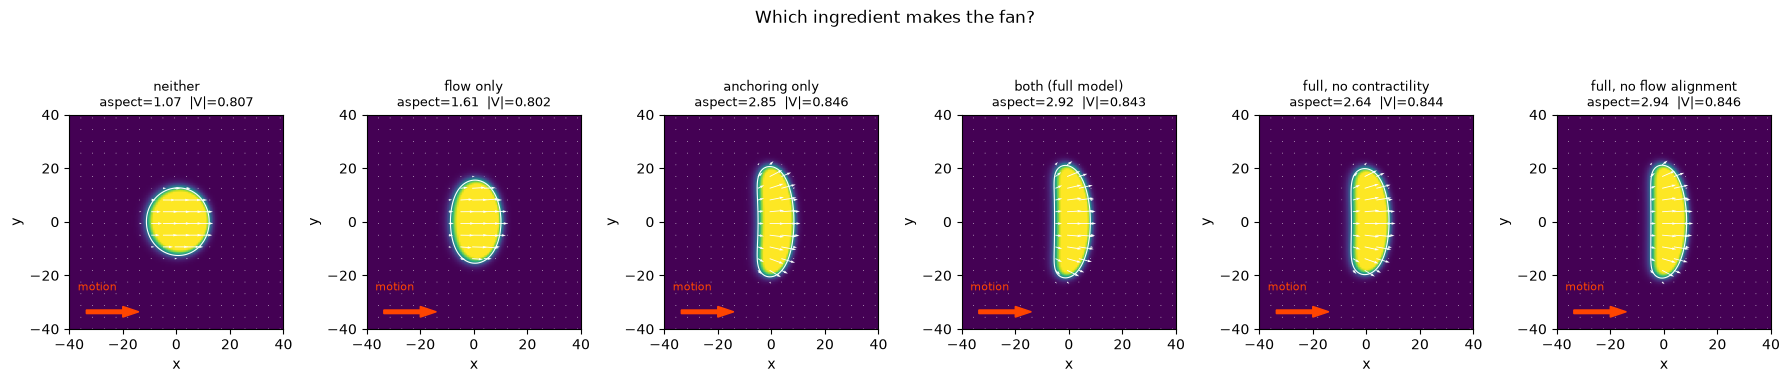

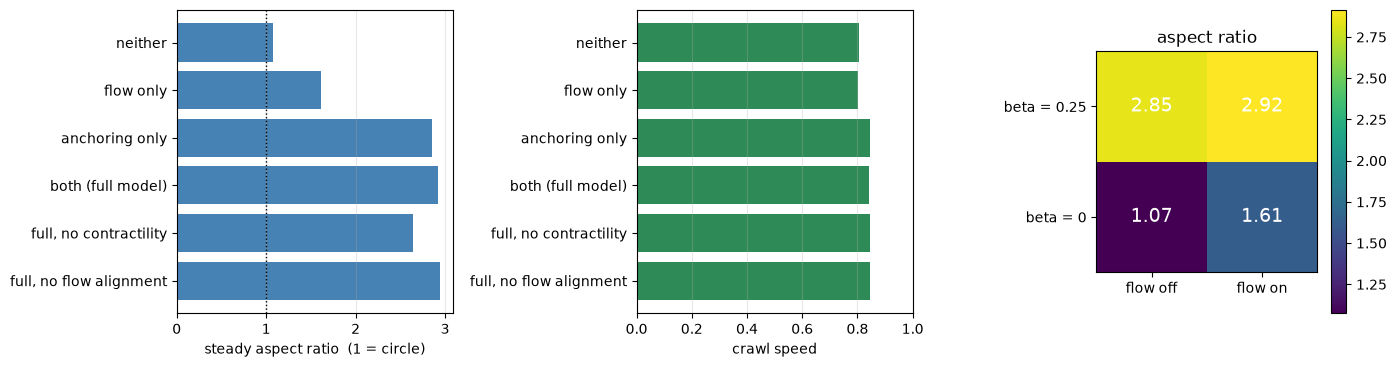

In [16]:
fig, axes = plt.subplots(1, len(decomp), figsize=(3.0 * len(decomp), 3.7))

for ax, (name, phi, Px, Py, vx, vy, d, _) in zip(axes, decomp):
    draw_cell(ax, phi, Px, Py, direction=final_direction(d), stride=7,
              title=f"{name}\naspect={d['aspect'][-1]:.2f}  "
                    f"|V|={d['speed'][-3:].mean():.3f}")

fig.suptitle("Which ingredient makes the fan?", y=1.03)
fig.tight_layout()
plt.show()


names = [n for n, *_ in decomp]
aspects = np.array([d["aspect"][-1] for _, _, _, _, _, _, d, _ in decomp])
speeds = np.array([d["speed"][-3:].mean() for _, _, _, _, _, _, d, _ in decomp])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].barh(names[::-1], aspects[::-1], color="steelblue")
ax[0].axvline(1.0, color="k", ls=":", lw=1)
ax[0].set_xlabel("steady aspect ratio  (1 = circle)")

ax[1].barh(names[::-1], speeds[::-1], color="seagreen")
ax[1].set_xlabel("crawl speed")
ax[1].set_xlim(0, 1.0)

# the 2 x 2 on its own
table = np.array([[aspects[0], aspects[1]], [aspects[2], aspects[3]]])
im = ax[2].imshow(table, origin="lower", cmap="viridis")
ax[2].set_xticks([0, 1], ["flow off", "flow on"])
ax[2].set_yticks([0, 1], ["beta = 0", "beta = 0.25"])
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, f"{table[i, j]:.2f}", ha="center", va="center",
                   color="w", fontsize=14)
ax[2].set_title("aspect ratio")
fig.colorbar(im, ax=ax[2])

ASPECT_NO_FLOW = aspects[2]      # "anchoring only" - reused in Section 16

for a in ax[:2]:
    a.grid(alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

### This is the most useful result in the notebook

Read the $2\times2$ first:

| | flow off | flow on |
|---|---|---|
| $\beta=0$ | $1.07$ | $1.61$ |
| $\beta=0.25$ | $2.85$ | $2.92$ |

- With **neither** ingredient the cell is a translating disc, aspect $1.07$.
  This is Version 1: $\mathbf u=w_0\mathbf P$ is uniform, so the cell can only
  move, not change shape.
- The **flow on its own** does deform the cell, $1.07\to1.61$. So adding
  hydrodynamics was not pointless; contractility acting through the flow is a
  genuine deformation mechanism, and it is the *only* one available when
  $\beta=0$.
- **Anchoring on its own** is far stronger, $1.07\to2.85$, and it needs no flow
  whatsoever — the splayed $\mathbf P$ makes $w_0\mathbf P$ non-uniform and that
  alone sculpts the fan.
- Adding the flow **on top of** anchoring buys almost nothing: $2.85\to2.92$,
  about $2\%$. The two mechanisms are strongly sub-additive.

The last two rows explain why that increment is so small: removing contractility
at $\beta=0.25$ *lowers* the aspect ratio to $2.64$, i.e. below the no-flow value
of $2.85$. So the flow contains two competing pieces — the contractile part
elongates the cell, the passive capillary and elastic part rounds it off — and at
these parameters they nearly cancel. Flow alignment ($\chi$) does essentially
nothing, $2.94$ versus $2.92$.

Crawl speed is $0.80$–$0.85$ in every row, because it is set by
$w_0\langle\mathbf P\rangle$ and none of these terms changes $\langle\mathbf P\rangle$ much.

**The practical conclusion**, which is not something the paper says and which
matters for how you spend effort: in this top-view geometry the fan shape is
predominantly *anchoring*-driven, not hydrodynamic. That is consistent with why
Tjhung *et al.* work in 3D — there the flow carries material into the
lamellipodium against the wall, and once the wall is gone the flow loses that
structural role.

The flow is still worth having: it is the only deformation mechanism available at
$\beta=0$, its contribution grows as adhesion weakens (Section 16), and
intracellular flow is exactly the quantity the experiments the paper cites
measure. But the comparison to the paper's Fig. 4 is blocked by our
$\mathbf k=0$ convention, as noted in Section 14.

# 16. Result 3 — substrate adhesion

$\xi$ is the adhesion strength: the effective friction that Leoni & Sens obtain
by averaging over the binding and unbinding of a carpet of linkers. In our force
balance it appears as $\xi+\eta k^{2}$, so it screens the flow over a length
$\ell=\sqrt{\eta/\xi}$: strong adhesion confines the flow to small scales, weak
adhesion lets it span the cell.

In [17]:
XI_LIST = np.array([0.125, 0.25, 0.5, 1.0, 2.0, 4.0])
if QUICK:
    XI_LIST = XI_LIST[::2]

xi_scan = {"speed": [], "aspect": [], "circ": [], "v_max": []}
xi_shapes = []

for value in XI_LIST:
    phi_x, Px_x, Py_x, vx_x, vy_x, d, _ = run_simulation(
        w0=1.0, zeta=-1.0, beta=0.25, xi=value, t_final=180.0 * TS)
    xi_scan["speed"].append(d["speed"][-3:].mean())
    xi_scan["aspect"].append(d["aspect"][-1])
    xi_scan["circ"].append(d["circularity"][-1])
    xi_scan["v_max"].append(d["v_max"][-1])
    xi_shapes.append((value, phi_x, vx_x, vy_x, final_direction(d)))

xi_scan = {k: np.array(v) for k, v in xi_scan.items()}

   w0=1     zeta=-1      beta=0.25    xi=0.125  [ 49.0s]  dV/V=-3.3e-16  speed=0.829  aspect=3.93


   w0=1     zeta=-1      beta=0.25    xi=0.25   [ 49.0s]  dV/V=+1.6e-16  speed=0.836  aspect=3.49


   w0=1     zeta=-1      beta=0.25    xi=0.5    [ 48.7s]  dV/V=-3.3e-16  speed=0.840  aspect=3.13


   w0=1     zeta=-1      beta=0.25    xi=1      [ 48.8s]  dV/V=+3.3e-16  speed=0.843  aspect=2.92


   w0=1     zeta=-1      beta=0.25    xi=2      [ 48.9s]  dV/V=+0.0e+00  speed=0.845  aspect=2.83


   w0=1     zeta=-1      beta=0.25    xi=4      [ 48.7s]  dV/V=-1.6e-16  speed=0.845  aspect=2.81


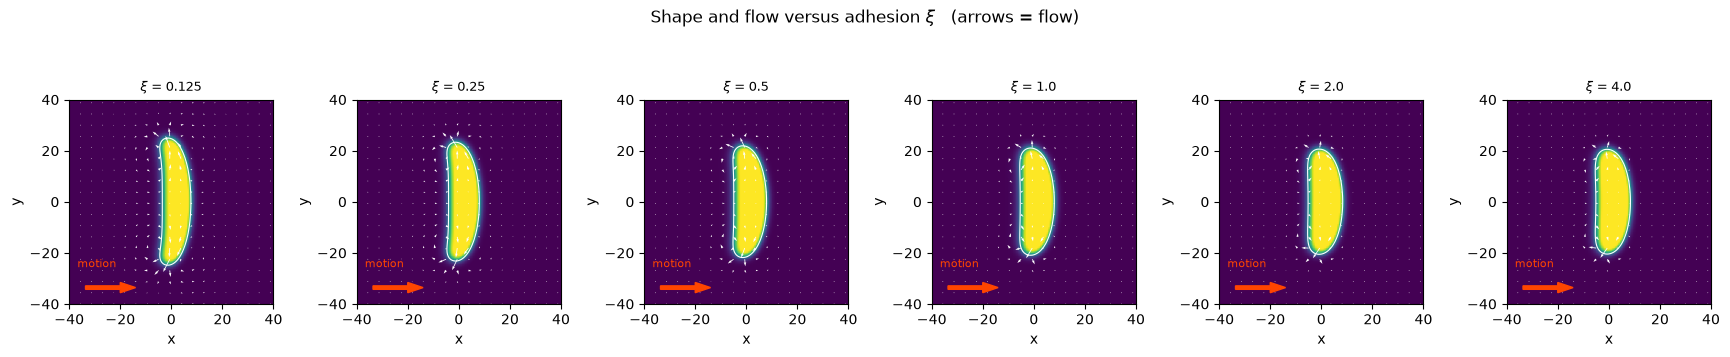

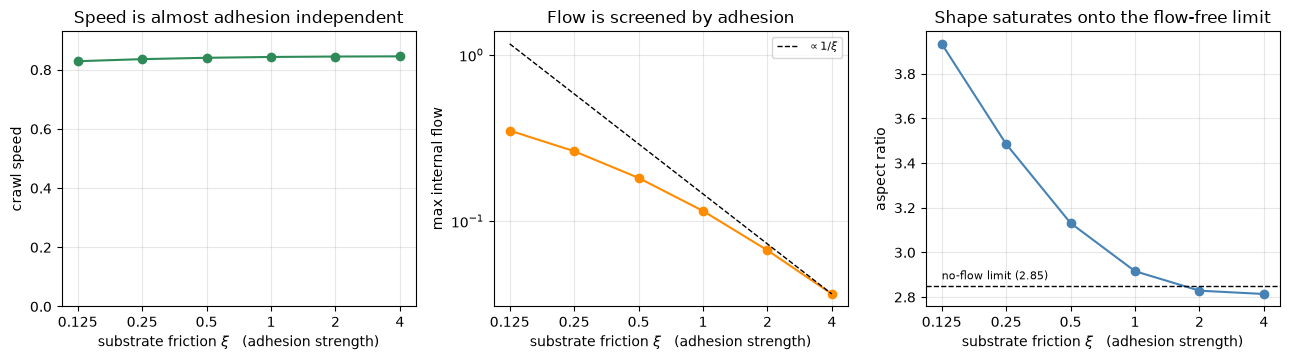

In [18]:
fig, axes = plt.subplots(1, len(xi_shapes), figsize=(2.9 * len(xi_shapes), 3.4))
for ax, (value, p, ux, uy, direction) in zip(axes, xi_shapes):
    draw_cell(ax, p, ux, uy, direction=direction, stride=7,
              title=r"$\xi$ = " + f"{value}")
fig.suptitle(r"Shape and flow versus adhesion $\xi$   (arrows = flow)", y=1.03)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 3, figsize=(13, 3.7))

ax[0].semilogx(XI_LIST, xi_scan["speed"], "o-", color="seagreen")
ax[0].set_ylabel("crawl speed")
ax[0].set_title("Speed is almost adhesion independent")
ax[0].set_ylim(0, 1.1 * xi_scan["speed"].max())

ax[1].loglog(XI_LIST, xi_scan["v_max"], "o-", color="darkorange")
ax[1].loglog(XI_LIST, xi_scan["v_max"][-1] * (XI_LIST / XI_LIST[-1])**-1.0,
             "k--", lw=1, label=r"$\propto 1/\xi$")
ax[1].set_ylabel("max internal flow")
ax[1].set_title("Flow is screened by adhesion")
ax[1].legend(fontsize=8)

ax[2].semilogx(XI_LIST, xi_scan["aspect"], "o-", color="steelblue")
ax[2].axhline(ASPECT_NO_FLOW, color="k", ls="--", lw=1)
ax[2].text(XI_LIST[0], ASPECT_NO_FLOW + 0.03,
           f"no-flow limit ({ASPECT_NO_FLOW:.2f})", fontsize=8)
ax[2].set_ylabel("aspect ratio")
ax[2].set_title("Shape saturates onto the flow-free limit")

for a in ax:
    a.set_xlabel(r"substrate friction $\xi$   (adhesion strength)")
    a.grid(alpha=0.3, which="major")
    a.set_xticks(XI_LIST)
    a.set_xticklabels([f"{v:g}" for v in XI_LIST])
    a.minorticks_off()

fig.tight_layout()
plt.show()

### Adhesion controls shape, not speed — and where we disagree with Leoni & Sens

Three clean observations.

1. **The internal flow is screened by adhesion**, falling by an order of
   magnitude over the range scanned and steepening towards $1/\xi$ at the strong
   adhesion end. That is what
   $\hat{\mathbf v}=\hat{\mathbf f}_\perp/(\xi+\eta k^{2})$ predicts: the pure
   $1/\xi$ law only holds once $\xi\gg\eta k^{2}$ for the wavenumbers that carry
   the flow, and at small $\xi$ the viscous term still competes, which is why the
   measured decay is shallower there.

2. **The crawl speed barely moves**, $0.829$ to $0.845$ across a $32$-fold
   change in adhesion. That is a direct consequence of the model's structure: the
   cell is transported by $\mathbf u=\mathbf v+w_0\mathbf P$, the mean of
   $\mathbf v$ vanishes, and so the speed is $w_0\langle\mathbf P\rangle$
   whatever the friction is.

3. **The shape depends on adhesion monotonically, and saturates.** The aspect
   ratio falls from $3.93$ at $\xi=0.125$ to $2.81$ at $\xi=4$ and then flattens.
   The value it flattens to is the useful part: Section 15 measured the
   **no-flow** aspect ratio at these parameters as $2.85$, and $\xi=4$ gives
   $2.81$. Strong adhesion screens the flow out of existence, and the model
   correctly limits onto its own flow-free version — an independent consistency
   check on the Stokes solve that costs nothing extra. Conversely, weak adhesion
   lets the active stress reach across the whole cell, and the flow's
   contribution to the shape becomes large.

Point 2 is a genuine **disagreement** with the Leoni & Sens paper, and it is
worth being explicit about rather than glossing over. Their central result is
that the migration speed is *strongly* adhesion dependent and biphasic, with a
maximum at a finite ratio of unbinding to binding rate (their Figs. 2a and 2b).
Our model cannot reproduce that, because the two papers put the motor in
different places:

- In Tjhung *et al.*, and therefore here, propulsion comes from **treadmilling**:
  filaments self-advect at $w_0$ relative to the fluid, and adhesion only damps
  the flow that this generates.
- In Leoni & Sens, propulsion comes from **traction**: oscillating force dipoles
  push against the substrate, and the net displacement per cycle exists *only*
  because the bonds are mechanosensitive, so that the drag differs between the
  protrusion and retraction phases of the cycle. Their Eq. (7) is proportional to
  $\lambda$, the stress sensitivity, and vanishes when $\lambda=0$.

Their mechanism is therefore invisible to a model with a constant $\xi$. Adding
it means making the friction depend on the local traction, e.g.
$\xi\to\xi(|\mathbf v|)$ following their Eq. (6), and giving the activity a
cycle so there is a phase difference to rectify. That is a well-defined extension
and it is listed in Section 18.

# 17. Result 4 — morphology diagram in $(\beta,\zeta)$

The paper's Fig. 3 holds $w_0$ fixed and maps the shapes as anchoring and
contractility vary. Same thing here. Each run starts fresh from a disc, so no
point inherits another's basin of attraction.

In [19]:
BETAS = np.array([0.0, 0.25, 0.5])
ZETAS = np.array([0.0, -1.0, -2.0])
if QUICK:
    BETAS, ZETAS = BETAS[::2], ZETAS[::2]

grid_shapes = {}
grid_aspect = np.zeros((len(BETAS), len(ZETAS)))
grid_speed = np.zeros_like(grid_aspect)

for i, b in enumerate(BETAS):
    for j, z in enumerate(ZETAS):
        phi_g, Px_g, Py_g, vx_g, vy_g, d, _ = run_simulation(
            w0=1.0, zeta=z, beta=b, t_final=120.0 * TS)
        grid_shapes[(i, j)] = (phi_g, Px_g, Py_g, final_direction(d))
        grid_aspect[i, j] = d["aspect"][-1]
        grid_speed[i, j] = d["speed"][-3:].mean()

   w0=1     zeta=0       beta=0       xi=1      [ 33.1s]  dV/V=+0.0e+00  speed=0.801  aspect=1.03


   w0=1     zeta=-1      beta=0       xi=1      [ 33.3s]  dV/V=+1.6e-16  speed=0.801  aspect=1.57


   w0=1     zeta=-2      beta=0       xi=1      [ 33.1s]  dV/V=+0.0e+00  speed=0.810  aspect=2.48


   w0=1     zeta=0       beta=0.25    xi=1      [ 33.2s]  dV/V=+0.0e+00  speed=0.845  aspect=2.63


   w0=1     zeta=-1      beta=0.25    xi=1      [ 33.2s]  dV/V=+3.3e-16  speed=0.844  aspect=2.95


   w0=1     zeta=-2      beta=0.25    xi=1      [ 32.8s]  dV/V=-1.6e-16  speed=0.842  aspect=3.25


   w0=1     zeta=0       beta=0.5     xi=1      [ 32.8s]  dV/V=+0.0e+00  speed=0.843  aspect=4.05


   w0=1     zeta=-1      beta=0.5     xi=1      [ 32.5s]  dV/V=-1.6e-16  speed=0.847  aspect=3.75


   w0=1     zeta=-2      beta=0.5     xi=1      [ 32.1s]  dV/V=+0.0e+00  speed=0.846  aspect=3.80


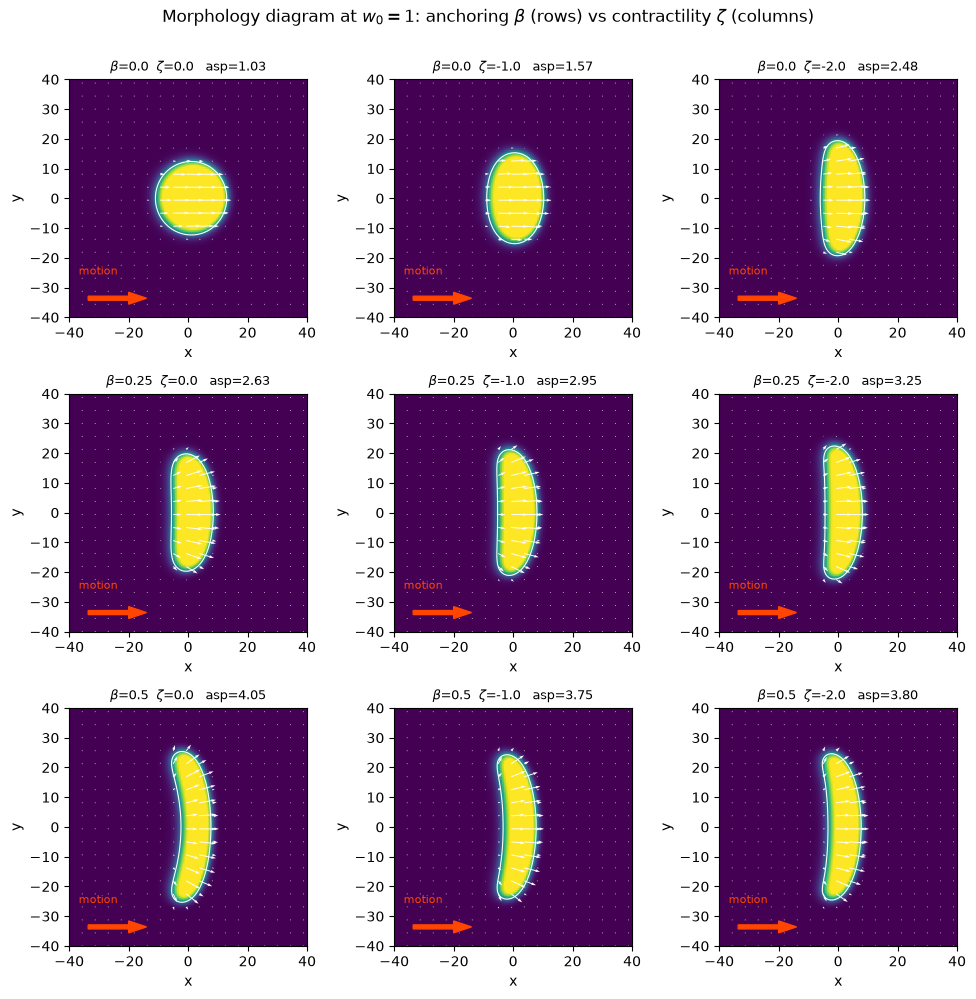

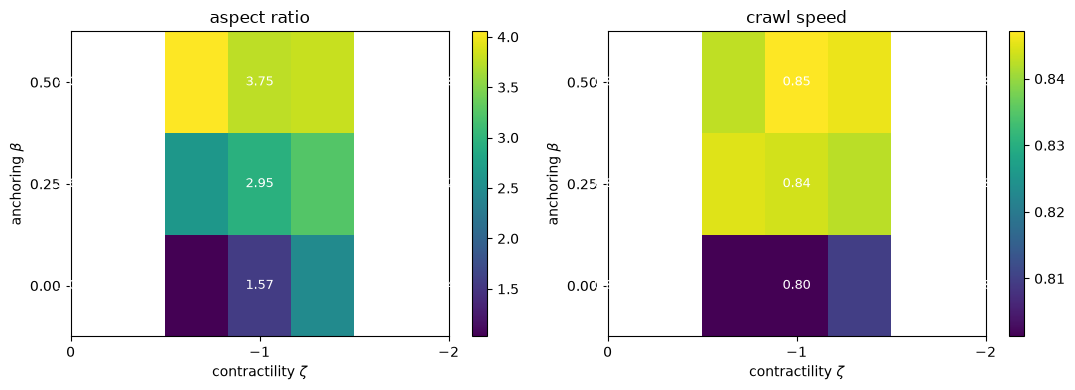

In [20]:
fig, axes = plt.subplots(len(BETAS), len(ZETAS),
                         figsize=(3.3 * len(ZETAS), 3.3 * len(BETAS)))
axes = np.atleast_2d(axes)

for i, b in enumerate(BETAS):
    for j, z in enumerate(ZETAS):
        phi_g, Px_g, Py_g, direction = grid_shapes[(i, j)]
        draw_cell(axes[i, j], phi_g, Px_g, Py_g, direction=direction, stride=7,
                  title=r"$\beta$" + f"={b}  " + r"$\zeta$" + f"={z}   "
                        f"asp={grid_aspect[i, j]:.2f}")

fig.suptitle(r"Morphology diagram at $w_0=1$: anchoring $\beta$ (rows) "
             r"vs contractility $\zeta$ (columns)", y=1.005)
fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, field, lab in [(ax[0], grid_aspect, "aspect ratio"),
                      (ax[1], grid_speed, "crawl speed")]:
    im = a.imshow(field, origin="lower", aspect="auto",
                  extent=[ZETAS[0] - 0.5, ZETAS[-1] + 0.5,
                          BETAS[0] - 0.125, BETAS[-1] + 0.125])
    a.set_xticks(ZETAS); a.set_yticks(BETAS)
    a.set_xlabel(r"contractility $\zeta$"); a.set_ylabel(r"anchoring $\beta$")
    a.set_title(lab)
    for i, b in enumerate(BETAS):
        for j, z in enumerate(ZETAS):
            a.text(z, b, f"{field[i, j]:.2f}", ha="center", va="center",
                   color="w", fontsize=9)
    fig.colorbar(im, ax=a)
fig.tight_layout()
plt.show()

The aspect ratios come out as

| | $\zeta=0$ | $\zeta=-1$ | $\zeta=-2$ |
|---|---|---|---|
| $\beta=0$ | $1.03$ | $1.57$ | $2.48$ |
| $\beta=0.25$ | $2.63$ | $2.95$ | $3.25$ |
| $\beta=0.5$ | $4.05$ | $3.75$ | $3.80$ |

which sharpens the picture from Section 15 in a way worth spelling out, because
the two parameters do **not** simply add.

- **Anchoring is the stronger knob.** Along the top row, going from $\beta=0$ to
  $\beta=0.5$ at $\zeta=0$ takes the aspect ratio from $1.03$ to $4.05$.
- **Contractility matters most when anchoring is absent.** In the $\beta=0$ row it
  does all the work, $1.03\to2.48$; that deformation is entirely hydrodynamic,
  since with $\beta=0$ and no flow the cell is a perfect disc.
- **The two saturate against each other.** By $\beta=0.5$, adding contractility
  slightly *reduces* the elongation ($4.05\to3.80$), because contraction along
  the polarization axis opposes the fan that anchoring is building.

The crawl speed is $0.80$–$0.85$ over the whole diagram.

Compared with the paper's Fig. 3 we recover its central trend — "fan-shaped
geometries emerge when $\beta$ is larger, due to the higher splay distortion of
the actin filaments arising at the leading edge" — and, from Section 14, that very
strong anchoring destroys motility altogether. We do not recover its
$\zeta$-driven transitions between distinct named shapes, for the geometric
reason given at the end of Section 14.

# 18. Where Version 3 stands

### Validated

- **Passive limit correct**: an ellipse relaxes to a circle, the free energy
  decreases monotonically, the flow dies to $\sim10^{-5}$, and the volume error
  is exactly zero. This exercises the Stokes solve, the capillary force sign and
  the conservative advection.
- **Volume conserved to machine precision** ($\sim10^{-16}$ relative) in every
  run, against $4.5\%$ drift in Version 1, and by construction rather than by
  accuracy.
- **Resolution independent**: $N=128$ and $N=160$ agree on speed and aspect ratio
  to about $1\%$.
- All reported states were confirmed **steady** by checking that the tail of the
  aspect-ratio trace is flat.

### Reproduced from Tjhung et al.

- The **non-motile aster** ("fried egg"): radial $\mathbf P$ with a $+1$ defect,
  $|\langle\mathbf P\rangle|=0$ and zero speed to machine precision (their
  Figs. 2a–c), together with the paper's explanation that motility needs the
  orientation field to break symmetry.
- The **lamellipodium / keratocyte fan**: broad convex leading edge with two
  trailing wings (their Figs. 2d–f).
- **Speed $\approx w_0$** in all motile states, and the requirement that motility
  needs $\mathbf P$ to break symmetry.
- The trend of their Fig. 3 that fans need larger anchoring.

### Not reproduced, and why

- **The pseudopod.** It is a near-substrate structure set by the vertical
  confinement of treadmilling, $w(z)=w_0e^{-z/\lambda}$. A top view has no $z$.
  The side-view Version 2 notebook does capture exactly this protrusion, so
  between the two versions the mechanism is covered — it just cannot be in the
  same plane.
- **The phagocytic cup.** Raising $\beta$ at $\zeta=0$ gives
  fan $\to$ strongly fanned $\to$ turning $\to$ aster, with no indented leading
  edge anywhere along the way. In the paper this shape is explicitly 3D.
- **Fried-egg spreading.** In 3D the cell spreads laterally while thinning
  vertically. At fixed area in a top view there is nothing to thin.
- **Adhesion-dependent speed.** Discussed at length in Section 16: our
  propulsion is treadmilling, theirs is mechanosensitive traction.
- **The lab-frame flow fields of their Fig. 4**, because we zero the
  $\mathbf k=0$ mode of $\mathbf v$ and so compute the internal circulation
  relative to the cell's own drift rather than the absolute flow.

### Honest caveat on the flow

The intracellular flow cost most of the new code, and Section 15 shows that on top
of anchoring it changes the cell shape by about $2\%$. That is not the same as
saying it does nothing: on its own it takes the aspect ratio from $1.07$ to
$1.61$, and at weak adhesion its contribution is large. But a reader should not
come away thinking the fan shape is hydrodynamic in origin here — at these
parameters it is predominantly anchoring-driven.

### Version 4

1. **Mechanosensitive adhesion**, to bring in the Leoni & Sens mechanism:
   $\xi\to\xi(|\mathbf v|)$ from their Eq. (6), with $\lambda>0$ for slip bonds
   and $\lambda<0$ for catch bonds, plus a cycle in the activity so there is a
   phase difference to rectify. This should make the speed adhesion dependent and
   is the natural way to test their biphasic prediction inside a continuum model.
2. **Spontaneous polarity**: at present $\mathbf P$ is put in by hand, either
   uniform or radial. A conserved two-component polarity module would let the
   cell choose its own direction and would let us ask which morphology is
   selected rather than imposing it.
3. **A third dimension, or the quasi-2D slice of Version 2 coupled to this
   solver**, which is what it would take to get the pseudopod and the
   fried-egg spreading in the same calculation.
4. **Cell–cell interaction**: two phase fields with a repulsive coupling, the
   route to collective crawling and wound healing.